In [1]:
import numpy as np
import pandas as pd
from tensorflow.keras import layers
from keras.models import Sequential
from keras.layers import Dense, Input
from keras.optimizers import Adam


In [2]:
from sklearn.datasets import make_moons
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

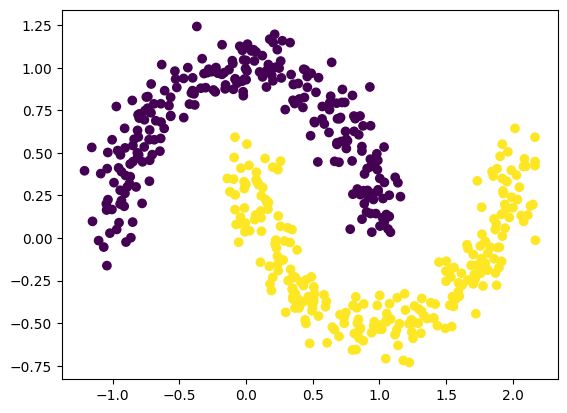

In [3]:
x,y = make_moons(n_samples=500, noise=0.1, random_state=42)
plt.scatter(x[:,0], x[:,1], c=y)
plt.show()

In [4]:
model = Sequential([
    Input(shape=(2,)),
    Dense(10, activation='sigmoid'),
    Dense(10, activation='sigmoid'),
    Dense(10, activation='sigmoid'),
    Dense(10, activation='sigmoid'),
    Dense(10, activation='sigmoid'),
    Dense(10, activation='sigmoid'),    
    Dense(10, activation='sigmoid'),
    Dense(10, activation='sigmoid'),
    Dense(10, activation='sigmoid'),
    Dense(1, activation='sigmoid')
])

In [14]:
model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])


In [15]:
old_weights = model.get_weights()[0]

In [16]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
model.fit(x_train, y_train, epochs=100, batch_size=32, validation_data=(x_test, y_test)) 

Epoch 1/100


13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 66ms/step - accuracy: 0.8875 - loss: 0.3028 - val_accuracy: 0.8100 - val_loss: 0.3980
Epoch 2/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8875 - loss: 0.3023 - val_accuracy: 0.8100 - val_loss: 0.3996
Epoch 3/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8875 - loss: 0.3020 - val_accuracy: 0.8100 - val_loss: 0.3983
Epoch 4/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8875 - loss: 0.3020 - val_accuracy: 0.8100 - val_loss: 0.3995
Epoch 5/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8875 - loss: 0.3015 - val_accuracy: 0.8100 - val_loss: 0.3981
Epoch 6/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8875 - loss: 0.3015 - val_accuracy: 0.8200 - val_loss: 0.3984
Epoch 7/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8875 - loss: 0.3014 - val_accuracy: 0.8100 - val_loss: 0.4006
Epoch 8/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8875 - loss: 0.3013 - val_accuracy: 0.8100 - val_loss: 0

In [17]:
new_weights = model.get_weights()[0]

In [20]:
old_weights

array([[ 0.85450464,  0.96796286, -0.9084344 , -1.1297448 ,  0.835073  ,
        -1.0971881 , -1.016127  ,  0.5983092 ,  0.6901178 , -3.0939102 ],
       [-1.9620034 , -2.1154175 ,  2.2349212 ,  2.4344492 , -2.2569194 ,
         1.9928962 ,  2.2129567 , -1.2297282 , -1.9422199 , -3.904814  ]],
      dtype=float32)

In [21]:
new_weights

array([[ 0.8593437 ,  0.96907467, -0.9245724 , -1.1296742 ,  0.85153246,
        -1.0755144 , -1.017408  ,  0.5989213 ,  0.7010535 , -3.3755355 ],
       [-1.697796  , -1.8574742 ,  1.975305  ,  2.194701  , -1.980395  ,
         1.7713983 ,  1.9726084 , -0.9643579 , -1.6634705 , -4.683898  ]],
      dtype=float32)

In [18]:
gradients = (new_weights - old_weights)/0.001
print('Gradients for first layer: ', gradients)

Gradients for first layer:  [[ 4.8390627e+00  1.1118054e+00 -1.6138016e+01  7.0571899e-02
   1.6459465e+01  2.1673677e+01 -1.2810229e+00  6.1208010e-01
   1.0935723e+01 -2.8162524e+02]
 [ 2.6420734e+02  2.5794327e+02 -2.5961624e+02 -2.3974823e+02
   2.7652441e+02 -2.2149788e+02 -2.4034821e+02  2.6537030e+02
   2.7874933e+02 -7.7908392e+02]]


In [19]:
percent_change = np.abs((old_weights - new_weights)/new_weights * 100)
print('Percentage change in weights for first layer: ', percent_change)

Percentage change in weights for first layer:  [[5.63111424e-01 1.14728570e-01 1.74545741e+00 6.24710228e-03
  1.93292272e+00 2.01519179e+00 1.25910446e-01 1.02197088e-01
  1.55989861e+00 8.34312916e+00]
 [1.55617847e+01 1.38867750e+01 1.31430969e+01 1.09239597e+01
  1.39630947e+01 1.25041275e+01 1.21842842e+01 2.75178223e+01
  1.67570972e+01 1.66332397e+01]]
